In [1]:
library(sf)
library(dplyr)

Linking to GEOS 3.10.2, GDAL 3.4.1, PROJ 8.2.1; sf_use_s2() is TRUE


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [2]:
shape <- st_read("/anvil/projects/tdm/sps/tippecanoe-project/Combined_Parcels_2024.shp") 
wkbk <- read.csv("/anvil/projects/tdm/sps/tippecanoe-project/Combined_Workbook_2023.csv")
wkbk2 <- read.csv("/anvil/projects/tdm/sps/tippecanoe-project/Combined_Workbook_2024.csv")
ctyb = st_read('tippecanoe/Combined_County_Boundaries_2024.shp')

Reading layer `Combined_Parcels_2024' from data source 
  `/anvil/projects/x-cis220051/sps/tippecanoe-project/Combined_Parcels_2024.shp' 
  using driver `ESRI Shapefile'


Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
"GDAL Message 1: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection."
Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
"GDAL Message 1: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection."
Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
"GDAL Message 1: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection."
Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
"GDAL Message 1: organizePolygons() recei

Simple feature collection with 3521572 features and 10 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 403530.9 ymin: 4180997 xmax: 692092.3 ymax: 4625472
Projected CRS: NAD83 / UTM zone 16N
Reading layer `Combined_County_Boundaries_2024' from data source 
  `/anvil/projects/x-cis220051/sps/tippecanoe-project/Combined_County_Boundaries_2024.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 92 features and 12 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 403540.1 ymin: 4180914 xmax: 692185.5 ymax: 4625472
Projected CRS: NAD83 / UTM zone 16N


In [3]:
wkbk = rbind(wkbk,wkbk2[wkbk2$County == 'Whitley',])

In [4]:
combined <- inner_join(shape, wkbk, by = c("PrclNmb" = "ParcelNumber"),relationship = "many-to-many")

In [5]:
combined$Area = as.numeric(combined$Area)
combined$Zip = as.numeric(combined$Zip)
combined = combined[!is.na(combined$Zip),]
combined$Zip = as.character(combined$Zip)
combined$Area <- st_area(combined)
combined$Area <- as.numeric(combined$Area)

Warning message:
"NAs introduced by coercion"


In [6]:
sfile = combined
combined <- st_drop_geometry(combined)

In [7]:
## Group Counties together and calculate parcel density (parcels/sq mi) across that county
## Classify Urban Counties (>= 100 parcels/sq mi) and Rural Counties (< 100 parcels/sq mi)
countygroups = combined %>%
  group_by(County.y) %>%
  summarise(
    ZipCodes = paste(unique(Zip), collapse = ", "),
    Townships = paste(unique(Township), collapse = ", "),
    TaxDistricts = paste(unique(TaxDistrict), collapse = ", "),
    Parcels = n(),
    Area = sum(Area, na.rm = TRUE) / 2.59e+6,
    Density = Parcels / Area
  ) %>%
  arrange(desc(Density))

countygroups$CountyClassification = ifelse(countygroups$Density >= 100, 'Urban', 'Rural')

head(countygroups)

County.y,ZipCodes,Townships,TaxDistricts,Parcels,Area,Density,CountyClassification
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>
Marion,"46240, 46218, 46259, 46256, 46203, 46278, 46225, 46220, 46201, 46236, 46229, 46219, 46202, 46237, 46239, 46221, 46226, 46235, 46204, 46205, 46260, 46222, 46254, 46250, 46208, 46268, 46228, 46227, 46217, 46241, 46113, 46234, 46107, 46216, 46077, 46214, 46224, 46231, 46183, 46055","Washington, Center, Franklin, Lawrence, Pike, Warren, Decatur, Wayne, Perry","800, 101, 300, 400, 600, 407, 700, 701, 724, 200, 401, 801, 901, 817, 601, 500, 474, 513, 811, 820, 822, 102, 770, 382, 302, 874, 716, 774, 900, 815, 982, 502, 914, 682, 674, 930, 970, 604, 805, 806, 809, 501, 904, 702, 876, 576, 574, 676, 320, 974, 976, 376, 476, 274, 270, 979, 201, 776, 570, 523, 520",341466,335.8736,1016.6503,Urban
Lake,"46409, 46394, 46375, 46321, 46307, 46327, 46322, 46303, 46319, 46323, 46342, 46406, 46373, 46404, 46405, 46402, 46320, 46311, 46403, 46341, 46410, 46312, 46407, 46324, 46408, 46356, 46376, 46377, 60411, 60438, 60417, 60617, 46310, 46368, 60633","Calumet, North, St. John, Center, West Creek, Hobart, Ross, Hanover, Winfield, Cedar Creek, Eagle Creek","4, 23, 36, 27, 42, 26, 37, 32, 18, 35, 3, 29, 14, 21, 34, 6, 17, 44, 13, 30, 24, 43, 7, 31, 15, 46, 22, 41, 16, 47, 8, 12, 45, 20, 1, 57, 38, 25, 55, 39, 60, 59, 56, 54, 28, 33, 19, 5, 2, 58",240204,518.8538,462.9512,Urban
Hamilton,"46074, 46033, 46062, 46037, 46040, 46038, 46034, 46032, 46060, 46290, 46030, 46077, 46256, 46280, 46069, 46055, 46250, 46031, 46236, 46011","Clay, Westfield Washington, Noblesville, Fall Creek, Delaware, Jackson, Adams, Wayne, White River","18, 15, 13, 20, 6, 11, 12, 5, 8, 21, 14, 7, 1, 16, 22, 17, 2, 9, 19, 10, 25, 23, 31, 35",141838,369.6066,383.7540,Urban
Vanderburgh,"47725, 47720, 47710, 47715, 47714, 47712, 47713, 47711, 47708, 47639, 47613, 47722, 42420","Scott, Center, Knight, Armstrong, Pigeon, Perry, Union, German","31, 19, 20, 27, 30, 17, 29, 24, 32, 25, 22, 26, 21, 18, 23, 28",79046,214.9410,367.7568,Urban
Floyd,"47136, 47122, 47150, 47119, 47117, 47124, 47165, 47106, 47172, 40212","Franklin, Georgetown, Greenville, New Albany, Lafayette","1, 2, 4, 7, 6, 3, 8, 5",39901,139.6362,285.7496,Urban
St. Joseph,"46552, 46628, 46616, 46637, 46635, 46617, 46545, 46561, 46530, 46554, 46556, 49120, 46601, 46619, 46613, 46614, 46615, 46544, 46506, 46574, 46536, 46550, 46573, 46563","Olive, Portage, Clay, Warren, German, Penn, Harris, Greene, Centre, Union, Lincoln, Liberty, Madison","18, 26, 3, 4, 17, 29, 9, 8, 7, 31, 11, 5, 22, 25, 36, 6, 37, 10, 2, 1, 33, 23, 30, 32, 27, 14, 15, 35, 34, 28, 16",118132,431.1735,273.9779,Urban


In [9]:
## % of Counties classified as Urban
round(nrow(countygroups[countygroups$CountyClassification == 'Urban',]) / nrow(countygroups) * 100,2)

[1] 27.17

In [10]:
library(ggplot2)

In [11]:
sfile = left_join(sfile,countygroups,by=c('County.y' = 'County.y'),relationship='many-to-many')

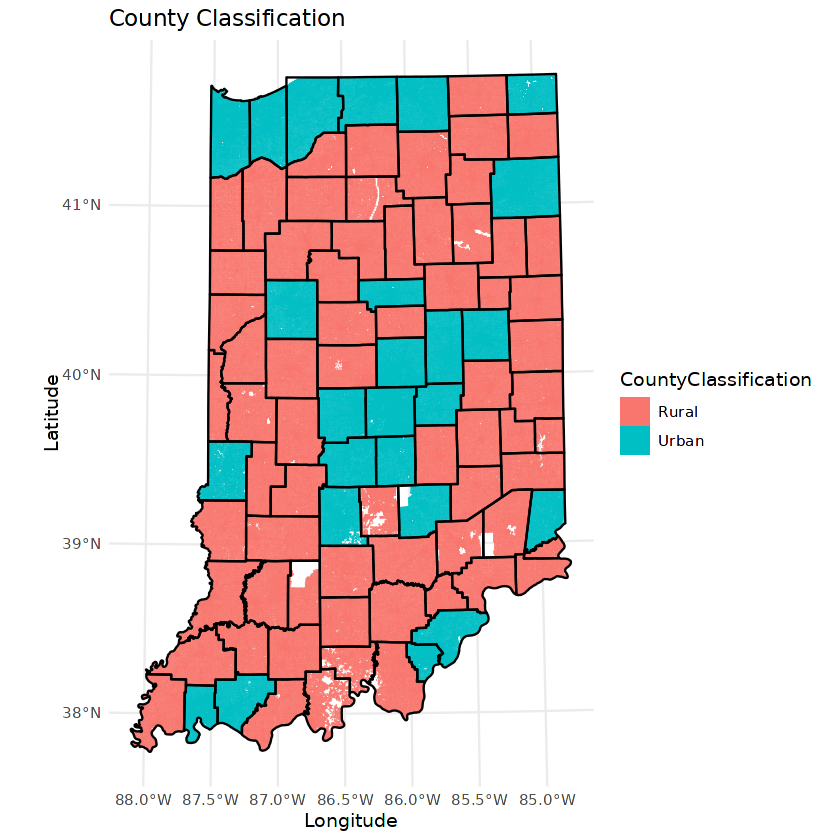

In [12]:
# Plots Urban/Rural Classifications at the County level
ggplot(sfile) + 
geom_sf(aes(geometry = geometry,fill=CountyClassification,color=CountyClassification), lwd = 0.05) +
geom_sf(data = ctyb, 
          fill = NA, color = "black", size = 0.5,lwd=0.5) +
theme_minimal() +
labs(title = "County Classification", x = "Longitude", y = "Latitude")

In [16]:
## Group Zip Codes together and calculate parcel density (parcels/sq mi) across that zip code
## Classify Urban Zip codes (>= 100 parcels/sq mi) and Rural zip codes (< 100 parcels/sq mi)
zipgroups = combined %>%
  group_by(Zip) %>%
  summarise(County = paste(unique(County.y), collapse = ", "),
            Townships = paste(unique(Township), collapse = ", "),
            TaxDistricts = paste(unique(TaxDistrict), collapse = ", "), Parcels = n(),
            Area = sum(Area,na.rm = TRUE) / 2.59e+6, Density = Parcels / Area) %>% 
  arrange(desc(Density))
zipgroups$ZipClassification = ifelse(zipgroups$Density >= 100,'Urban','Rural')
head(zipgroups[zipgroups$Parcels > 100,])

Zip,County,Townships,TaxDistricts,Parcels,Area,Density,ZipClassification
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>
46201,Marion,Center,101,14393,4.24281501,3392.323,Urban
47901,Tippecanoe,Fairfield,4,1244,0.37772654,3293.388,Urban
46613,St. Joseph,Portage,26,5802,1.83933543,3154.400,Urban
46407,Lake,Calumet,4,10198,3.25779533,3130.338,Urban
47871,Vigo,Riley,"20, 18",108,0.03755466,2875.808,Urban
46048,Madison,Green,"15, 14",1589,0.55295428,2873.655,Urban


In [17]:
## % of zip codes classified as Urban
round(nrow(zipgroups[zipgroups$ZipClassification == 'Urban',]) / nrow(zipgroups) * 100,2)

[1] 39.51

In [18]:
sfile = left_join(sfile,zipgroups,by=c('Zip' = 'Zip'),relationship='many-to-many')

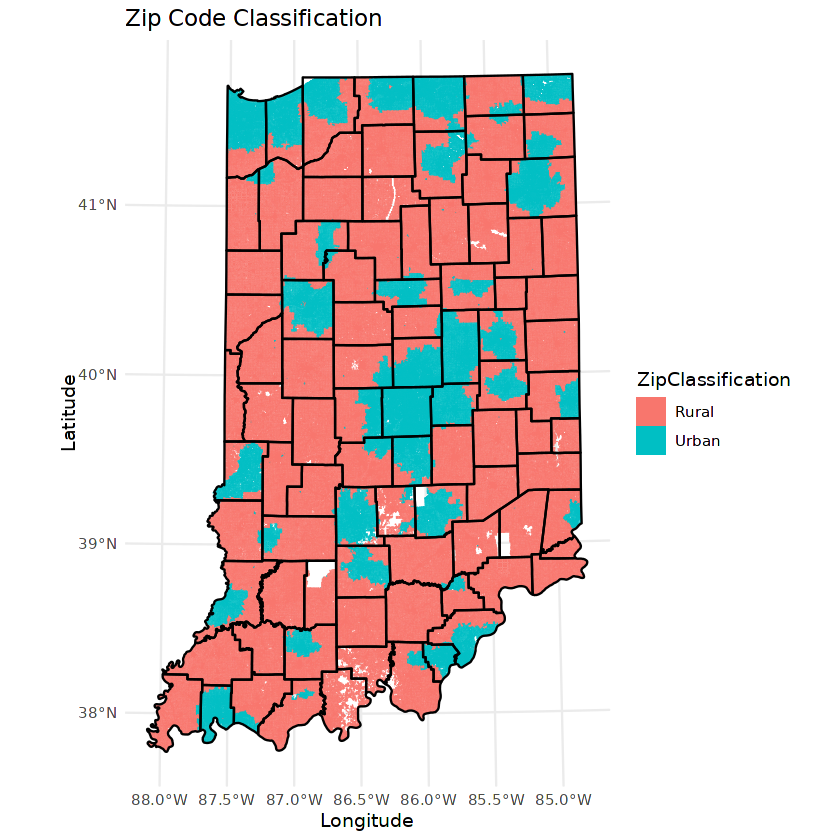

In [19]:
# Plots Urban/Rural Classifications at the Zip Code level
ggplot(sfile) + 
geom_sf(aes(geometry = geometry,fill=ZipClassification,color=ZipClassification), lwd = 0.05) +
geom_sf(data = ctyb, 
          fill = NA, color = "black", size = 0.5,lwd=0.5) +
theme_minimal() +
labs(title = "Zip Code Classification", x = "Longitude", y = "Latitude")

In [20]:
## Group Taxing Districts together and calculate parcel density (parcels/sq mi) across that district
## Classify Urban Taxing Districts (>= 100 parcels/sq mi) and Rural Taxing Districts (< 100 parcels/sq mi)
combined$TaxDistrict = as.character(combined$TaxDistrict)
taxgroups = combined %>%
  group_by(County.y,TaxDistrict) %>%
  summarise(Townships = paste(unique(Township), collapse = ", "),
            ZipCodes = paste(unique(Zip), collapse = ", "), Parcels = n(),
            Area = sum(Area,na.rm = TRUE) / 2.59e+6, Density = Parcels / Area) %>% 
  arrange(desc(Density))
taxgroups$TaxClassification = ifelse(taxgroups$Density >= 100,'Urban','Rural')
head(taxgroups[taxgroups$Parcels > 100,])

`summarise()` has grouped output by 'County.y'. You can override using the
`.groups` argument.


County.y,TaxDistrict,Townships,ZipCodes,Parcels,Area,Density,TaxClassification
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>
Pulaski,14,Salem,47946,715,0.24157424,2959.753,Urban
Tipton,4,Jefferson,46049,295,0.10044465,2936.941,Urban
Clinton,14,Perry,46035,557,0.19182575,2903.677,Urban
Vigo,20,Riley,"47871, 47802",141,0.05103476,2762.823,Urban
Shelby,15,Noble,47272,137,0.05268626,2600.298,Urban
Knox,12,Vigo,47512,2087,0.81032251,2575.518,Urban


In [21]:
## % of taxing districts classified as Urban
round(nrow(taxgroups[taxgroups$TaxClassification == 'Urban',]) / nrow(taxgroups) * 100,2)

[1] 48.31

In [23]:
taxgroups$TaxDistrict = as.numeric(taxgroups$TaxDistrict)
sfile = left_join(sfile,taxgroups,by=c('TaxDistrict' = 'TaxDistrict','County.y' = 'County.y'),relationship='many-to-many')

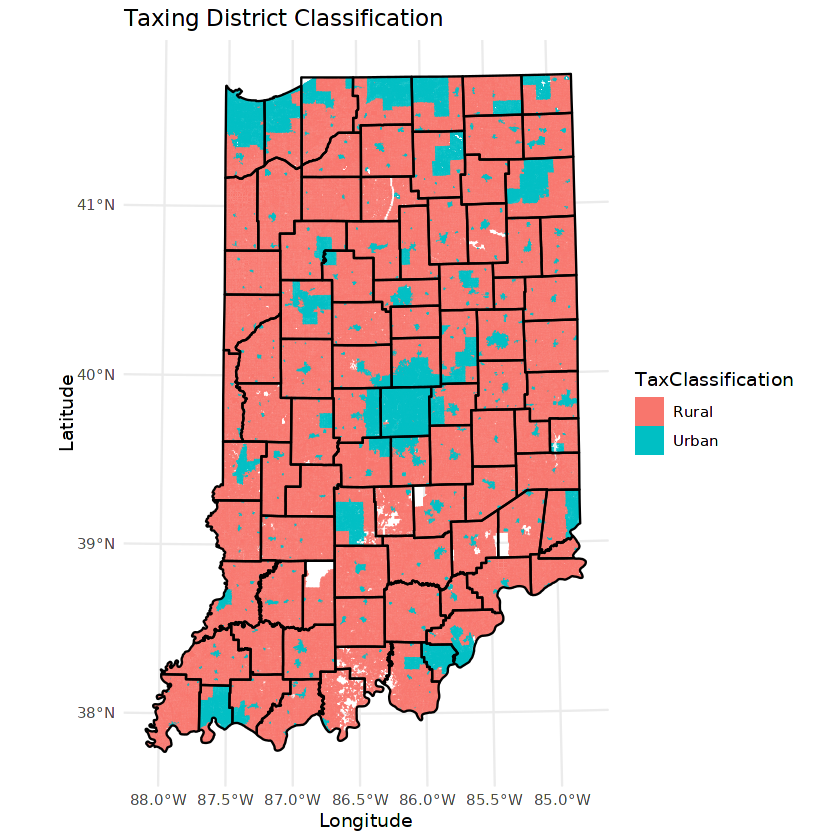

In [24]:
# Plots Urban/Rural Classifications at the Taxing District level
ggplot(sfile) + 
geom_sf(aes(geometry = geometry,fill=TaxClassification,color=TaxClassification), lwd = 0.05) + 
geom_sf(data = ctyb, 
          fill = NA, color = "black", size = 0.5,lwd=0.5) +
theme_minimal() +
labs(title = "Taxing District Classification", x = "Longitude", y = "Latitude")

In [25]:
## Group Townships together and calculate parcel density (parcels/sq mi) across that township
## Classify Urban Townships (>= 100 parcels/sq mi) and Rural Townships (< 100 parcels/sq mi)
townshipgroups = combined %>%
  group_by(County.y,Township) %>%
  summarise(ZipCodes = paste(unique(Zip), collapse = ", "),
            TaxDistricts = paste(unique(TaxDistrict), collapse = ", "),
             Parcels = n(),
            Area = sum(Area,na.rm = TRUE) / 2.59e+6, Density = Parcels / Area) %>% 
  arrange(desc(Density))
townshipgroups$TownshipClassification = ifelse(townshipgroups$Density >= 100,'Urban','Rural')
head(townshipgroups[townshipgroups$Parcels > 100,])

`summarise()` has grouped output by 'County.y'. You can override using the
`.groups` argument.


County.y,Township,ZipCodes,TaxDistricts,Parcels,Area,Density,TownshipClassification
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>
Marion,Center,"46218, 46225, 46201, 46202, 46203, 46204, 46205, 46221, 46208, 46222, 46107, 46226","101, 102",70418,31.645365,2225.223,Urban
Vanderburgh,Pigeon,"47710, 47713, 47711, 47712, 47708, 47720, 42420","29, 28",15275,8.158821,1872.207,Urban
St. Joseph,Portage,"46628, 46616, 46617, 46637, 46556, 46601, 46619, 46613, 46614, 46615, 46544","26, 25",41680,27.907172,1493.523,Urban
Vigo,Harrison,"47802, 47807, 47803, 47804, 47809, 47805",2,25245,17.304048,1458.907,Urban
Lake,Calumet,"46409, 46406, 46404, 46402, 46403, 46407, 46408, 46410, 46405, 46319, 46312, 46368","4, 3, 1, 5, 2",57785,45.670546,1265.257,Urban
Allen,Wayne,"46819, 46816, 46809, 46807, 46806, 46804, 46802, 46803, 46808, 46805","68, 74, 67",45450,36.568860,1242.861,Urban


In [26]:
## % of townships classified as Urban
round(nrow(townshipgroups[townshipgroups$TownshipClassification == 'Urban',]) / nrow(townshipgroups) * 100,2)

[1] 20.24

In [27]:
sfile = left_join(sfile,townshipgroups,by=c('Township' = 'Township','County.y' = 'County.y'),relationship='many-to-many')

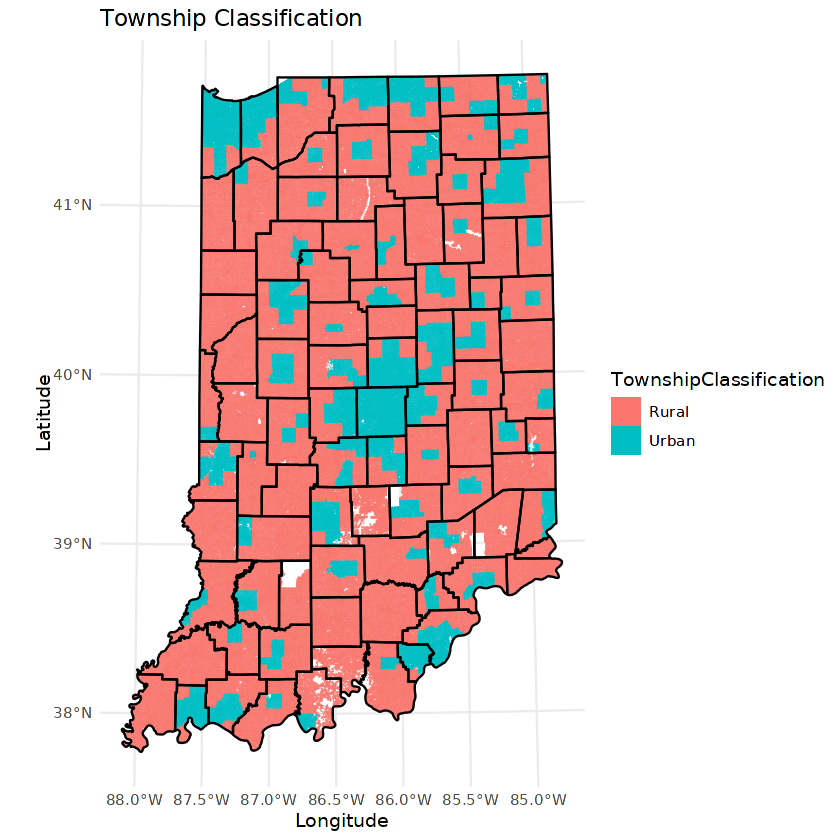

In [28]:
# Plots Urban/Rural Classifications at the Township level
ggplot(sfile) + 
geom_sf(aes(geometry = geometry,fill=TownshipClassification,color=TownshipClassification), lwd = 0.05) + 
geom_sf(data = ctyb, 
          fill = NA, color = "black", size = 0.5,lwd=0.5) +
theme_minimal() +
labs(title = "Township Classification", x = "Longitude", y = "Latitude")

In [29]:
sfile = st_drop_geometry(sfile)

In [30]:
sfile = sfile[,c(1,5,11,12,13,24,31,37,43)]

In [31]:
colnames(sfile)[colnames(sfile) == 'PrclNmb'] = 'ParcelNumber'
colnames(sfile)[colnames(sfile) == 'County.y'] = 'County'

In [32]:
head(sfile)

,ParcelNumber,Zip,County,Township,TaxDistrict,CountyClassification,ZipClassification,TaxClassification,TownshipClassification
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,01-05-35-200-001.000-020,46772,Adams,Washington,20,Rural,Rural,Rural,Urban
2,01-07-11-301-003.001-003,46714,Adams,French,3,Rural,Rural,Rural,Rural
3,01-02-19-300-010.500-013,46733,Adams,Root,13,Rural,Rural,Rural,Urban
4,01-02-19-300-012.000-013,46733,Adams,Root,13,Rural,Rural,Rural,Urban
5,01-02-35-101-002.002-014,46733,Adams,Root,14,Rural,Rural,Urban,Urban
6,01-05-31-100-001.500-020,46772,Adams,Washington,20,Rural,Rural,Rural,Urban


In [51]:
write.csv(sfile, 'tippecanoe/Parcel_Classifications_2023.csv')